##  **Business Problem: Analyze the factors influencing employee attrition and build a predictive model to identify whether an employee is likely to leave the organization based on their characteristics.**

#### **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [4]:
df=pd.read_csv('Employee Attrition (1).csv')
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


### **Data Exploration**

In [5]:
df.shape

(59598, 24)

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Employee ID               59598 non-null  int64
 1   Age                       59598 non-null  int64
 2   Gender                    59598 non-null  str  
 3   Years at Company          59598 non-null  int64
 4   Job Role                  59598 non-null  str  
 5   Monthly Income            59598 non-null  int64
 6   Work-Life Balance         59598 non-null  str  
 7   Job Satisfaction          59598 non-null  str  
 8   Performance Rating        59598 non-null  str  
 9   Number of Promotions      59598 non-null  int64
 10  Overtime                  59598 non-null  str  
 11  Distance from Home        59598 non-null  int64
 12  Education Level           59598 non-null  str  
 13  Marital Status            59598 non-null  str  
 14  Number of Dependents      59598 non-null  int64
 

In [7]:
df.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,37227.118729,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,21519.150028,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,1.000000,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,18580.250000,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,37209.500000,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,55876.750000,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


### **Missing Values**

In [8]:
df.isnull().sum()

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

### **Data Cleaning**

In [9]:
df=df.drop(columns='Employee ID')

In [10]:
import re

df.columns = [
    re.sub(r'[^a-zA-Z0-9]+', '_', col).strip('_').lower()
    for col in df.columns
]

In [11]:
df.columns

Index(['age', 'gender', 'years_at_company', 'job_role', 'monthly_income',
       'work_life_balance', 'job_satisfaction', 'performance_rating',
       'number_of_promotions', 'overtime', 'distance_from_home',
       'education_level', 'marital_status', 'number_of_dependents',
       'job_level', 'company_size', 'company_tenure', 'remote_work',
       'leadership_opportunities', 'innovation_opportunities',
       'company_reputation', 'employee_recognition', 'attrition'],
      dtype='str')

### **Checking Target balance**

In [12]:
df['attrition'].unique()

<ArrowStringArray>
['Stayed', 'Left']
Length: 2, dtype: str

In [13]:
df['attrition'].value_counts() #Target classes are mostly balanced

attrition
Stayed    31260
Left      28338
Name: count, dtype: int64

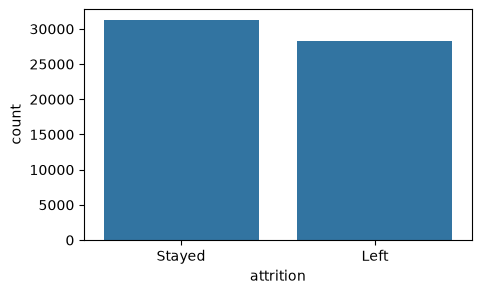

In [14]:
plt.figure(figsize=(5,3))
sns.countplot(x='attrition',data=df)
plt.show()

### **Outlier check**

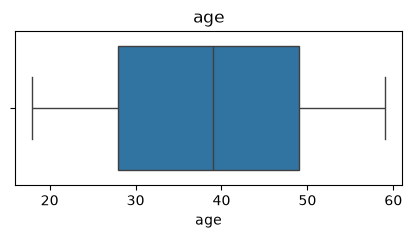

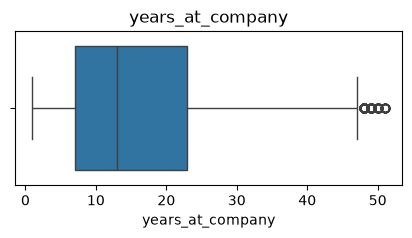

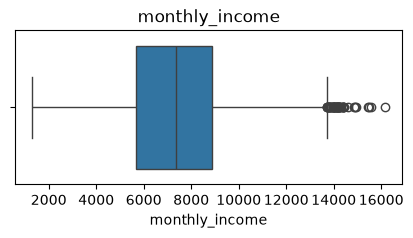

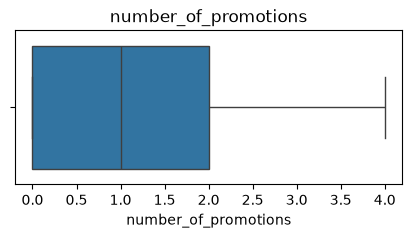

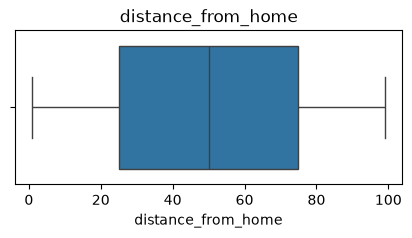

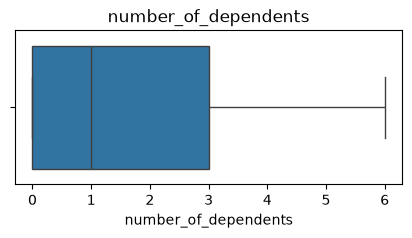

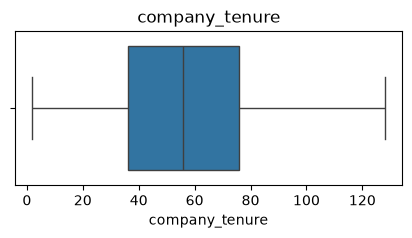

In [15]:
numerical_cols=df.select_dtypes(include=['int64','float64'])
for i in numerical_cols:
  plt.figure(figsize=(5,2))
  sns.boxplot(x=i,data=df)
  plt.title(i)
  plt.show()

In [16]:
numerical_cols=df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols=df.select_dtypes(exclude=['int64','float64']).columns.tolist()

# Remove Attrition from categorical_cols as it is the target variable

if 'attrition' in categorical_cols:
    categorical_cols.remove('attrition')

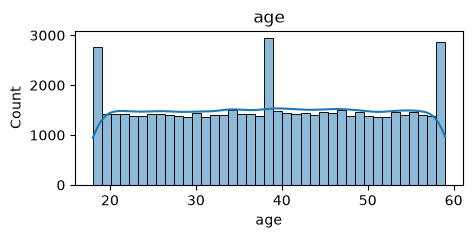

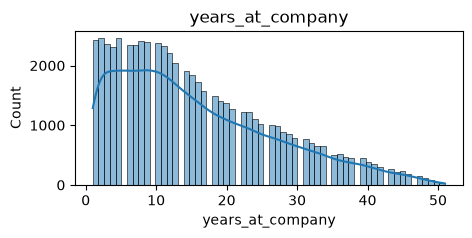

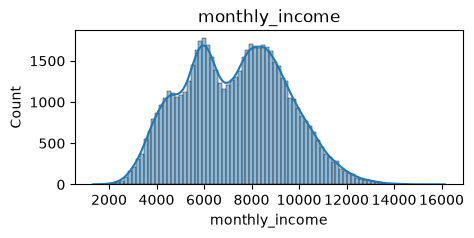

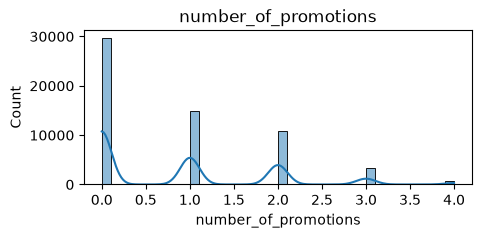

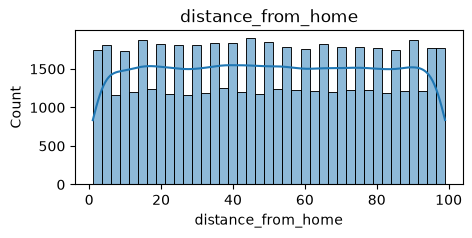

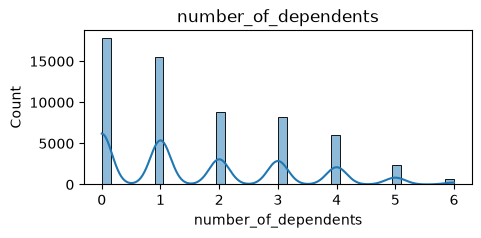

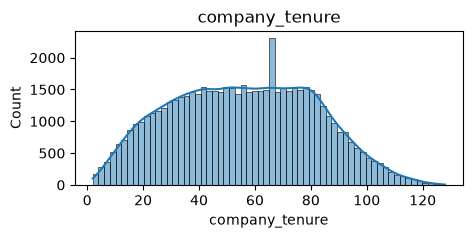

In [18]:
#univariate analysis for numerical columns

for col in numerical_cols:
  plt.figure(figsize=(5,2))
  sns.histplot(df[col],kde=True)
  plt.title(col)
  plt.show()

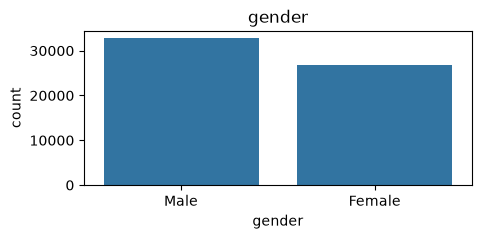

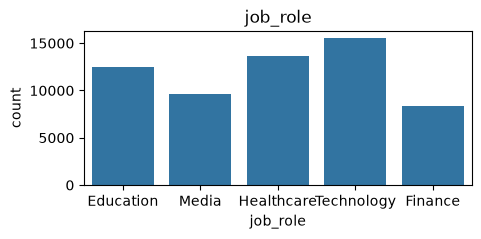

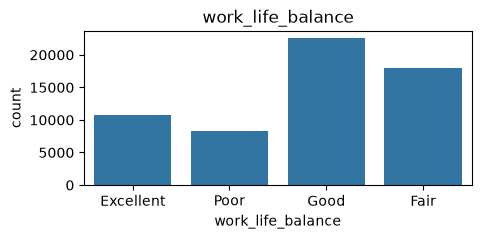

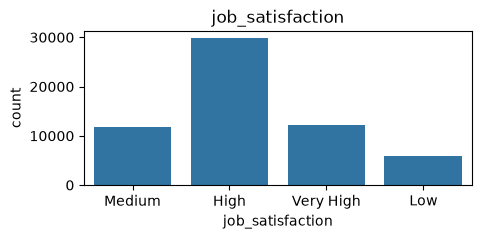

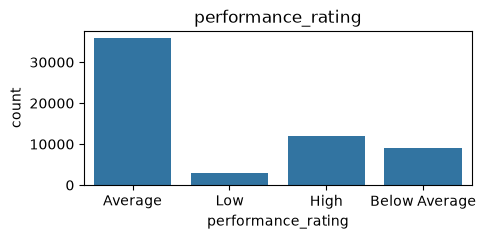

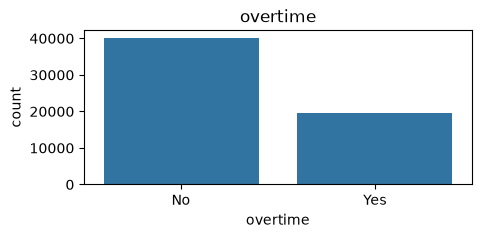

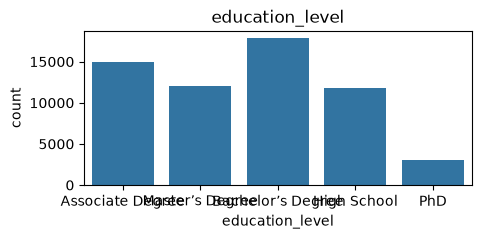

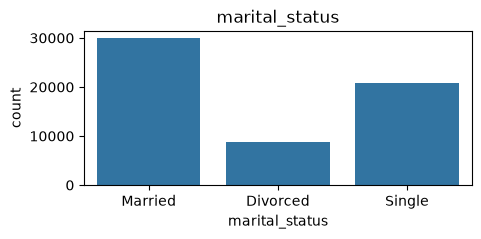

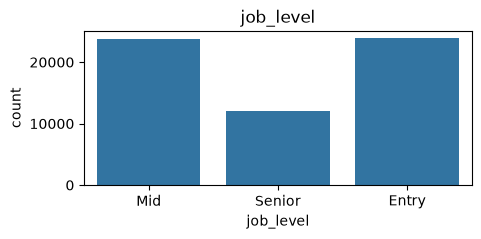

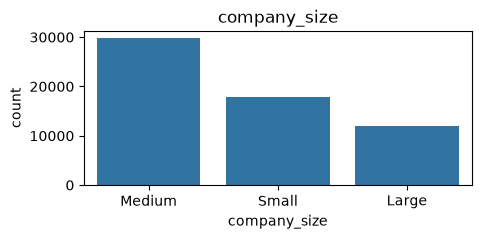

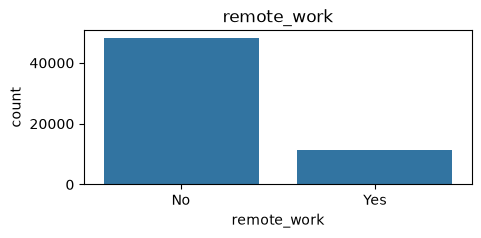

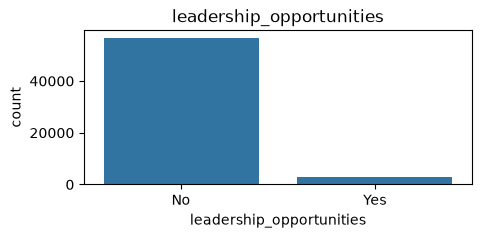

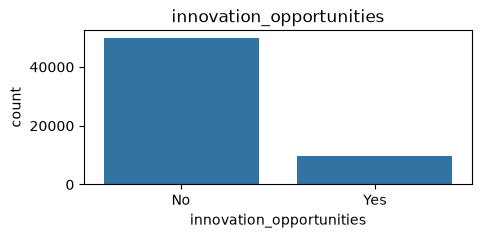

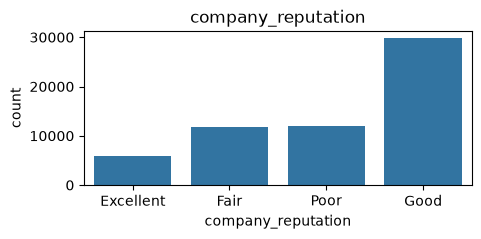

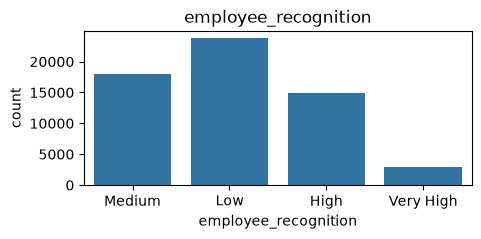

In [20]:
#univariate analysis for categorical columns
for col in categorical_cols:
  plt.figure(figsize=(5,2))
  sns.countplot(x=df[col])
  plt.title(col)
  plt.show()

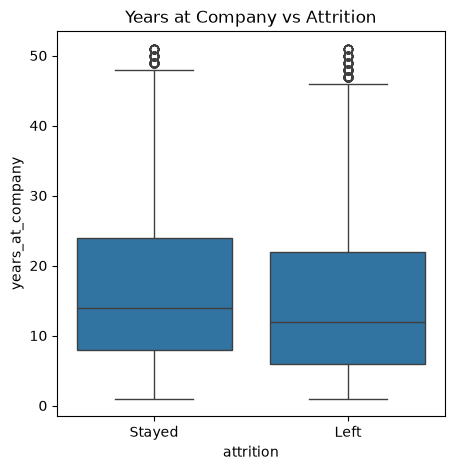

In [19]:
#bivariate Analysis

plt.figure(figsize=(5,5))
sns.boxplot(x='attrition', y='years_at_company', data=df)
plt.title('Years at Company vs Attrition')
plt.show()

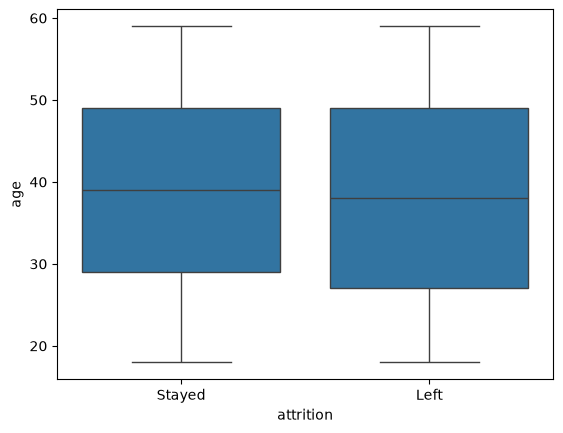

In [22]:
sns.boxplot(data=df, x='attrition', y='age')
plt.show()

### **Correlation check**

<Axes: >

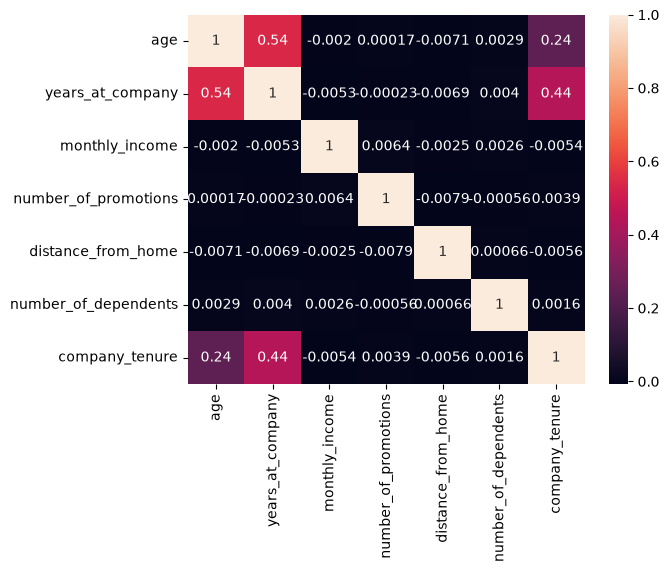

In [23]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

### **Features & Target**

In [21]:
X=df.drop(columns='attrition')
y=df['attrition']

### **Train-Test_Split**

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(47678, 22)
(11920, 22)
(47678,)
(11920,)


### **Data Preprocessing**

- Scaling & Encoding

In [24]:
#Pipeline for Numerical_cols
num_pipe=Pipeline([('imputer',SimpleImputer(strategy='median')),
                    ('scaler',StandardScaler())])

#pipeline for categorical_cols
cat_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent'))
                  ,('onehot',OneHotEncoder(handle_unknown='ignore'))])

#ColumnTransformer
preprocessor=ColumnTransformer(
          transformers=[
          ('num',num_pipe,numerical_cols),
          ('cat',cat_pipe,categorical_cols)
          ], remainder='drop'
        )


### **Model Building**

#### **KNN Classifier**

In [25]:

from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([('preprocessor', preprocessor),
                     ("Knn_model", KNeighborsClassifier())])

knn_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Knn_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Left','Stayed']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['age','gender','years_at_company',...,'innovation_opportunities', 'company_reputation','employee_recognition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``

#### **Logistic Regression**

In [26]:
from sklearn.linear_model import LogisticRegression

logistic_pipe=Pipeline([('Preprocessor',preprocessor),('LR',LogisticRegression())])

logistic_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessor', ...), ('LR', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Left','Stayed']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['age','gender','years_at_company',...,'innovation_opportunities', 'company_reputation','employee_recognition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

#### **DecisionTree Classifier**

In [27]:
from sklearn.tree import DecisionTreeClassifier

decision_pipe=Pipeline([('Preprocessor',preprocessor),('DT',DecisionTreeClassifier())])

decision_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessor', ...), ('DT', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Left','Stayed']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['age','gender','years_at_company',...,'innovation_opportunities', 'company_reputation','employee_recognition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

#### **RandomForest Classifier**

In [28]:
from sklearn.ensemble import RandomForestClassifier

forest_pipe=Pipeline([('Preprocessor',preprocessor),('RFC',RandomForestClassifier())])

forest_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessor', ...), ('RFC', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Left','Stayed']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['age','gender','years_at_company',...,'innovation_opportunities', 'company_reputation','employee_recognition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

### **Evaluation**

In [29]:
models={'knn':knn_pipe,
        'logisti_Regression':logistic_pipe,
        'Decision_tree':decision_pipe,
        'Random_forest':forest_pipe}


In [30]:
for name,model in models.items():
  print(f'Model : {name}')
  y_pred=model.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  print(f'accuracy_score : {accuracy}')
  print('-'*30)

Model : knn
accuracy_score : 0.6740771812080537
------------------------------
Model : logisti_Regression
accuracy_score : 0.7473993288590604
------------------------------
Model : Decision_tree
accuracy_score : 0.6659395973154363
------------------------------
Model : Random_forest
accuracy_score : 0.7411912751677853
------------------------------


In [31]:
#Classification_report
for name,model in models.items():
  print(f'Model : {name}')
  y_pred=model.predict(X_test)
  print(classification_report(y_test,y_pred))
  print('-'*60)

Model : knn
              precision    recall  f1-score   support

        Left       0.65      0.67      0.66      5667
      Stayed       0.69      0.68      0.68      6253

    accuracy                           0.67     11920
   macro avg       0.67      0.67      0.67     11920
weighted avg       0.67      0.67      0.67     11920

------------------------------------------------------------
Model : logisti_Regression
              precision    recall  f1-score   support

        Left       0.73      0.74      0.73      5667
      Stayed       0.76      0.76      0.76      6253

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920

------------------------------------------------------------
Model : Decision_tree
              precision    recall  f1-score   support

        Left       0.65      0.65      0.65      5667
      Stayed       0.68      0.68      0.68      6253


#### **Confusion Matrix**

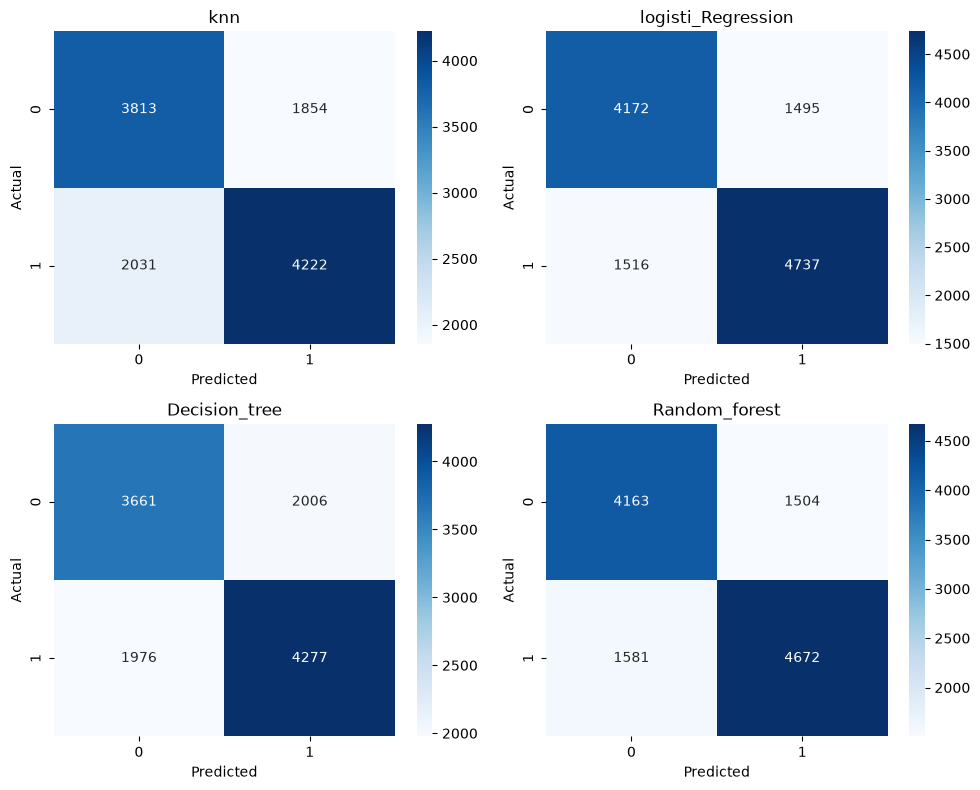

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, model) in zip(axes.flat, models.items()):
  y_pred = model.predict(X_test) # Get predictions from the model
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax)
  ax.set_title(name)
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### **HyperParameter Tuning**

In [33]:
from sklearn.model_selection import RandomizedSearchCV



model_pipeline = Pipeline(
    [('preprocessor', preprocessor),
    ('lr', LogisticRegression())]
)

param_grid={
    "lr__C":[0.001,0.1,1,10,100],
    "lr__penalty":["l2"],
    "lr__solver": ['liblinear', 'lbfgs', 'saga'],
    "lr__max_iter": [500, 1000]
        }

random_search=RandomizedSearchCV(
    model_pipeline,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    random_state=42,
    verbose=True
    )

random_search.fit(X_train,y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


C:\Users\swamy\Desktop\Employee_Atrrition\.env\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\swamy\Desktop\Employee_Atrrition\.env\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\swamy\D

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'lr__C': [0.001, 0.1, ...], 'lr__max_iter': [500, 1000], 'lr__penalty': ['l2'], 'lr__solver': ['liblinear', 'lbfgs', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretur

In [34]:
# Model with best estimator and parameters
model=random_search.best_estimator_


In [35]:
random_search.best_params_

{'lr__solver': 'saga', 'lr__penalty': 'l2', 'lr__max_iter': 500, 'lr__C': 1}

In [36]:
y_pred=model.predict(X_test)

In [37]:
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.7468120805369127

In [38]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

        Left       0.73      0.74      0.73      5667
      Stayed       0.76      0.76      0.76      6253

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920



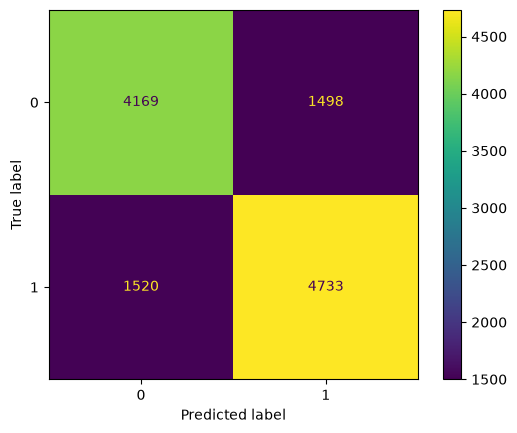

In [39]:
rs=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(rs).plot()

In [40]:

model=random_search.best_estimator_
import joblib

joblib.dump(model, "employee_attrition.pkl")

['employee_attrition.pkl']